# Filtre de Kalman

Dans ce note book, nous allons explorer l'utilisation du filtre de Kalman.

### 1. Système 


In [113]:
def get_disturbances(t, scenario, params):
    # Valeurs par défaut (Tableau 4.1 / Sections 4.2 & 4.3)
    p1l, p2l = params['g1']['PL'], params['g2']['PL'] # 400 et 600 MW
    kl = params['KL'] # 3064 MW/rad

    if scenario == 'EL1': # Augmentation linéaire : 100 MW en 60s
        p1l = 400 + (100 / 60) * min(t, 60)
    elif scenario == 'EL2': # Augmentation linéaire : 200 MW en 60s
        p1l = 400 + (200 / 60) * min(t, 60)
    elif scenario == 'SL1': # Échelon de charge à 15s : 500 MW
        if t >= 15: p1l = 500
    elif scenario == 'SL2': # Échelon de charge à 15s : 600 MW
        if t >= 15: p1l = 600
    elif scenario == 'PLT': # Coupure de ligne à 15s
        if t >= 15: kl = 1532 # Passage de 3064 à 1532 MW/rad

    return p1l, p2l, kl

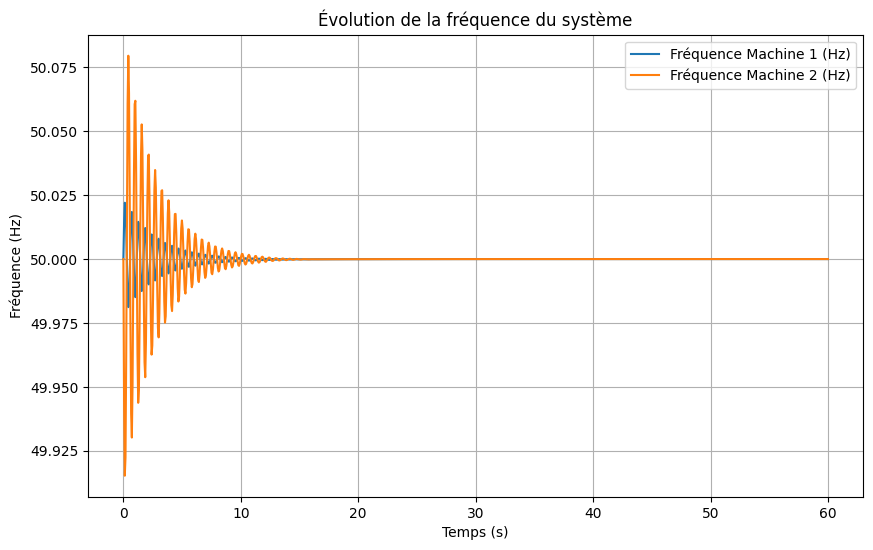

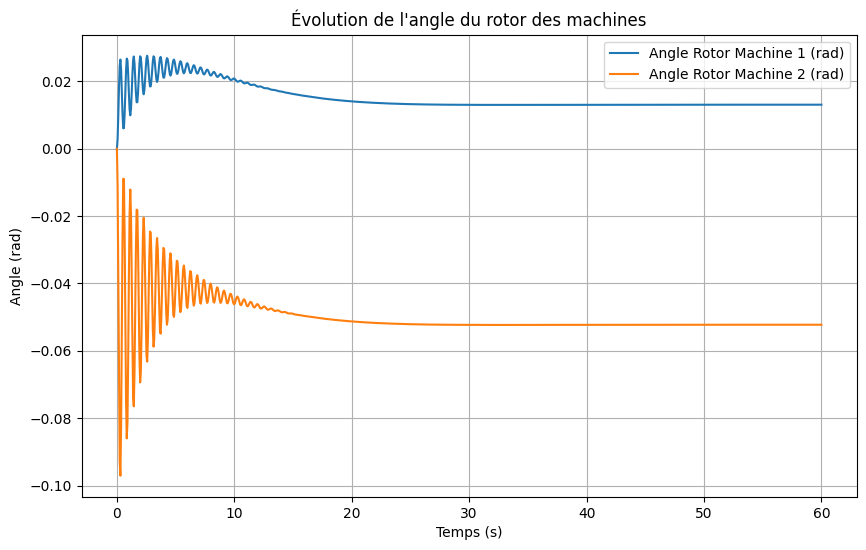

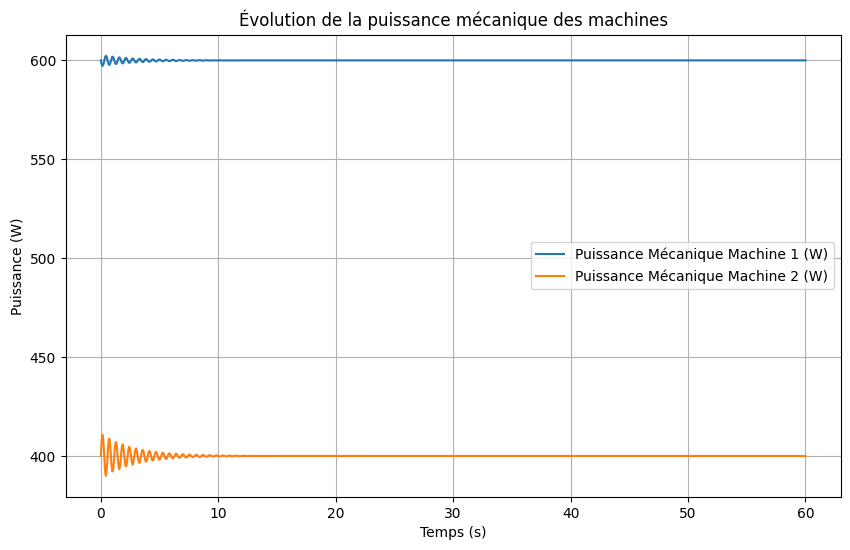

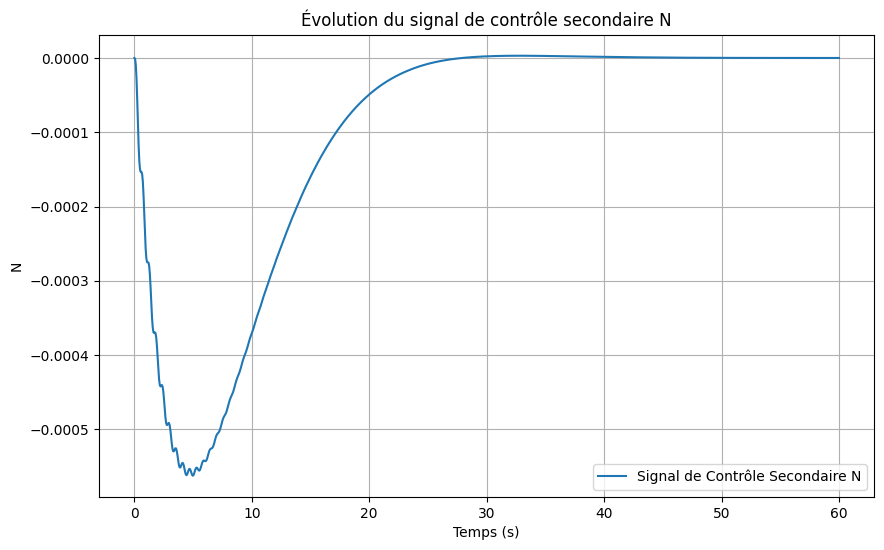

In [114]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def power_system_model(t, x, params):
    # Variables d'état
    theta1, omega1, T1m, theta2, omega2, T2m, N = x
    
    p1l , p2l, kl = get_disturbances(t, 'False', params)
    params['g1']['PL'] = p1l
    params['g2']['PL'] = p2l
    params['KL'] = kl
    
    w0 = params['omega0']
    
    # --- Équations Algébriques ---
    # Puissance échangée (Ligne)
    F12 = params['KL'] * np.sin(theta1 - theta2)
    F21 = -F12
    
    # Puissance demandée aux générateurs (Charge + Ligne)
    P1G = params['g1']['PL'] + F12
    P2G = params['g2']['PL'] + F21
    
    # Puissance mécanique actuelle
    P1m = T1m * omega1
    P2m = T2m * omega2
    
    # Consigne de puissance (Control secondaire N inclus)
    P1c = np.clip(params['g1']['P0'] + N * params['g1']['Pr'], params['g1']['Pmin'], params['g1']['Pmax'])
    P2c = np.clip(params['g2']['P0'] + N * params['g2']['Pr'], params['g2']['Pmin'], params['g2']['Pmax'])

    # --- Équations Différentielles ---
    # Générateur 1
    d_theta1 = omega1 - w0
    d_omega1 = (T1m - (P1G/omega1) - params['g1']['D']*(omega1 - w0)) / params['g1']['J']
    
    # Contrôle primaire G1 (avec condition if/else)
    if params['g1']['Pmin'] <= P1m <= params['g1']['Pmax']:
        d_T1m = -params['g1']['alpha'] * (P1m - P1c) - params['g1']['beta'] * (omega1 - w0)
    else:
        d_T1m = 0

    # Générateur 2
    d_theta2 = omega2 - w0
    d_omega2 = (T2m - (P2G/omega2) - params['g2']['D']*(omega2 - w0)) / params['g2']['J']
    
    # Contrôle primaire G2
    if params['g2']['Pmin'] <= P2m <= params['g2']['Pmax']:
        d_T2m = -params['g2']['alpha'] * (P2m - P2c) - params['g2']['beta'] * (omega2 - w0)
    else:
        d_T2m = 0

    # Contrôle Secondaire (Fréquence moyenne pondérée)
    omega_r = (params['g1']['J']*omega1 + params['g2']['J']*omega2) / (params['g1']['J'] + params['g2']['J'])
    if -1 <= N <= 1:
        dN = -params['Ks'] * (omega_r - w0)
    else:
        dN = 0

    return [d_theta1, d_omega1, d_T1m, d_theta2, d_omega2, d_T2m, dN]

# --- Initialisation des données (Tableau 4.1 et sections 4.2/4.3) ---
w0_rad = 2 * np.pi * 50

data = {
    'omega0': w0_rad,
    'KL': 3064, # Pour deux lignes selon doc
    'Ks': 0.05,
    'g1': {'P0': 600, 'Pmin': 0, 'Pmax': 1000, 'Pr': 100, 'J': 0.4, 'D': 0.04, 'alpha': 100, 'beta': 2000, 'PL': 400},
    'g2': {'P0': 400, 'Pmin': 0, 'Pmax': 600, 'Pr': 50, 'J': 0.1, 'D': 0.02, 'alpha': 100, 'beta': 2000, 'PL': 600}
}

params = {
    'f0': 50.0,
    'omega0': 2 * np.pi * 50.0,
    'KL_nom': 3064.0,   # MW/rad (deux lignes)
    'KL_one': 1532.0,   # Une seule ligne
    'Ks': 0.05,
    'g1': {
        'P0': 600.0, 'Pmin': 0.0, 'Pmax': 1000.0, 'Pr': 100.0,
        'J': 0.4, 'D': 0.04, 'alpha': 100.0, 'beta': 2000.0, 'PL0': 400.0
    },
    'g2': {
        'P0': 400.0, 'Pmin': 0.0, 'Pmax': 600.0, 'Pr': 50.0,
        'J': 0.1, 'D': 0.02, 'alpha': 100.0, 'beta': 2000.0, 'PL0': 600.0
    },
    't_event': 15.0,
    'scenario': 'loadRamp1' # Choix : 'loadRamp1', 'loadRamp2', 'loadStep1', 'loadStep2', 'lineTrip'
}

# Conditions initiales à l'équilibre
# On estime T_initial = P_charge / omega0
x0 = [0, w0_rad, data['g1']['P0']/w0_rad, 0, w0_rad, data['g2']['P0']/w0_rad, 0]
#-np.arcsin((data['g1']['P0'] - data['g1']['PL']) / data['KL'])
# Simulation
t_span = (0, 60)
t_eval = np.linspace(0, 60, 1000)

sol = solve_ivp(power_system_model, t_span, x0, args=(data,), t_eval=t_eval, method='Radau')

theta1_sim = sol.y[0]
theta2_sim = sol.y[3]
F12_sim = data['KL'] * (theta1_sim - theta2_sim)

P1G_sim = data['g1']['PL'] + F12_sim
P2G_sim = data['g2']['PL'] + F12_sim

# --- Graphique ---
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[1]/(2*np.pi), label='Fréquence Machine 1 (Hz)')
plt.plot(sol.t, sol.y[4]/(2*np.pi), label='Fréquence Machine 2 (Hz)')
plt.title("Évolution de la fréquence du système")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='Angle Rotor Machine 1 (rad)')
plt.plot(sol.t, sol.y[3], label='Angle Rotor Machine 2 (rad)')
plt.title("Évolution de l'angle du rotor des machines")     
plt.xlabel("Temps (s)")
plt.ylabel("Angle (rad)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[2]*sol.y[1], label='Puissance Mécanique Machine 1 (W)')
plt.plot(sol.t, sol.y[5]*sol.y[4], label='Puissance Mécanique Machine 2 (W)')
plt.title("Évolution de la puissance mécanique des machines")       
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[6], label='Signal de Contrôle Secondaire N')
plt.title("Évolution du signal de contrôle secondaire N")       
plt.xlabel("Temps (s)")
plt.ylabel("N")
plt.grid(True)
plt.legend()
plt.show()


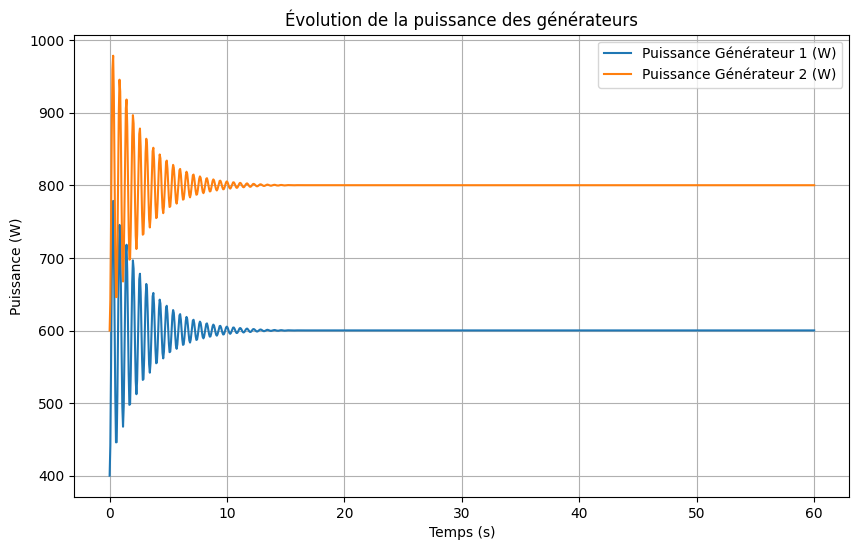

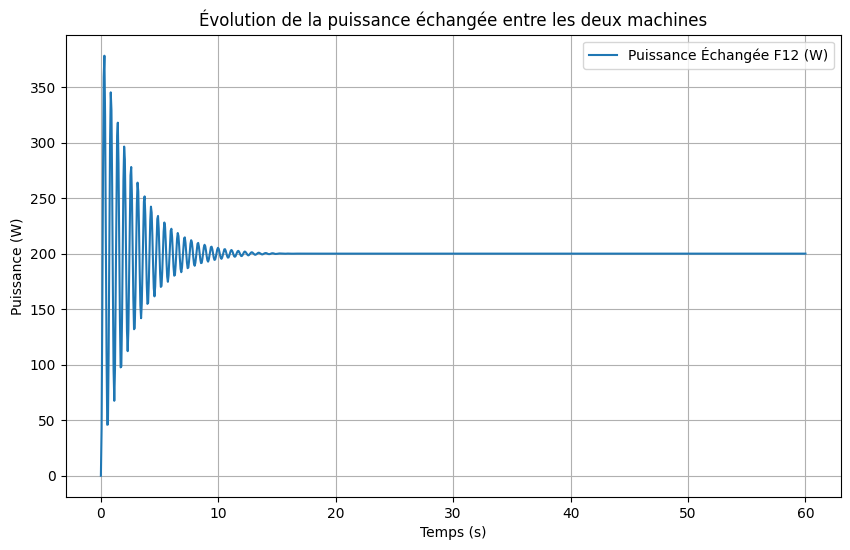

In [115]:
plt.figure(figsize=(10, 6)) 
plt.plot(sol.t, P1G_sim, label='Puissance Générateur 1 (W)')
plt.plot(sol.t, P2G_sim, label='Puissance Générateur 2 (W)')
plt.title("Évolution de la puissance des générateurs")  
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, F12_sim, label='Puissance Échangée F12 (W)')
plt.title("Évolution de la puissance échangée entre les deux machines")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.grid(True)
plt.legend()
plt.show()

In [116]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.integrate import solve_ivp

# # ==========================================================
# # 1. Configuration des Paramètres (Tableau 4.1 & Notebook)
# # ==========================================================
# params = {
#     'f0': 50.0,
#     'omega0': 2 * np.pi * 50.0,
#     'KL_nom': 3064.0,   # MW/rad (deux lignes)
#     'KL_one': 1532.0,   # Une seule ligne
#     'Ks': 0.05,
#     'g1': {
#         'P0': 600.0, 'Pmin': 0.0, 'Pmax': 1000.0, 'Pr': 100.0,
#         'J': 0.4, 'D': 0.04, 'alpha': 100.0, 'beta': 2000.0, 'PL0': 400.0
#     },
#     'g2': {
#         'P0': 400.0, 'Pmin': 0.0, 'Pmax': 600.0, 'Pr': 50.0,
#         'J': 0.1, 'D': 0.02, 'alpha': 100.0, 'beta': 2000.0, 'PL0': 600.0
#     },
#     't_event': 15.0,
#     'scenario': 'loadRamp1' # Choix : 'loadRamp1', 'loadRamp2', 'loadStep1', 'loadStep2', 'lineTrip'
# }

# # ==========================================================
# # 2. Définition du Système Différentiel (ODE)
# # ==========================================================
# def power_system_ode(t, x, p):
#     # Désassemblage du vecteur d'état X
#     theta1, theta2, w1, w2, Tm1, Tm2, N = x
#     w0 = p['omega0']
    
#     # --- Gestion des Événements (Disturbances) ---
#     delta_PL1 = 0.0
#     KL = p['KL_nom']
    
#     sc = p['scenario']
#     if sc == 'loadRamp1':
#         delta_PL1 = 100 / 60 # +100MW en 1min
#     elif sc == 'loadRamp2':
#         delta_PL1 = 200 / 60
#     elif sc == 'loadStep1' and t >= p['t_event']:
#         PL1 = 500.0 # Échelon à 500MW
#     elif sc == 'loadStep2' and t >= p['t_event']:
#         PL1 = 600.0 # Échelon à 600MW
#     elif sc == 'lineTrip' and t >= p['t_event']:
#         KL = p['KL_one']

#     # --- Équations Algébriques ---
#     dPL1 = delta_PL1 if sc.startswith('loadRamp') else 0.0
#     PL1 = p['g1']['PL0'] + dPL1*t
#     F12 = KL * np.sin(theta1 - theta2)
#     PG1 = PL1 + F12
#     PG2 = p['g2']['PL0'] - F12
    
#     # Fréquence centrale
#     wr = (p['g1']['J']*w1 + p['g2']['J']*w2) / (p['g1']['J'] + p['g2']['J'])

#     # --- Équations Différentielles ---
#     # Contrôle Secondaire (N)
#     dN = -p['Ks']*(wr - w0) if abs(N) <= 1.0 else 0.0
    
#     # Évolution de la charge (Rampes)
#     dPL1 = delta_PL1 if sc.startswith('loadRamp') else 0.0
#     dPL2 = 0.0

#     # Machine 1
#     Pc1 = np.clip(p['g1']['P0'] + N * p['g1']['Pr'], p['g1']['Pmin'], p['g1']['Pmax'])
#     Pm1 = Tm1 * w1
#     dTm1 = -p['g1']['alpha']*(Pm1 - Pc1) - p['g1']['beta']*(w1 - w0) if (p['g1']['Pmin'] <= Pm1 <= p['g1']['Pmax']) else 0.0
#     dw1 = (Tm1 - PG1/w1 - p['g1']['D']*(w1 - w0)) / p['g1']['J']
#     dtheta1 = w1 - w0

#     # Machine 2
#     Pc2 = np.clip(p['g2']['P0'] + N * p['g2']['Pr'], p['g2']['Pmin'], p['g2']['Pmax'])
#     Pm2 = Tm2 * w2
#     dTm2 = -p['g2']['alpha']*(Pm2 - Pc2) - p['g2']['beta']*(w2 - w0) if (p['g2']['Pmin'] <= Pm2 <= p['g2']['Pmax']) else 0.0
#     dw2 = (Tm2 - PG2/w2 - p['g2']['D']*(w2 - w0)) / p['g2']['J']
#     dtheta2 = w2 - w0

#     return [dtheta1, dtheta2, dw1, dw2, dTm1, dTm2, dN]

# # ==========================================================
# # 3. Initialisation et Simulation
# # ==========================================================
# # Conditions initiales à l'équilibre (t=0)
# x0 = [
#     0.0,                               # theta1
#     np.arcsin((params['g1']['PL0'] - params['g1']['P0']) / params['KL_nom']), # theta2
#     params['omega0'],                  # w1
#     params['omega0'],                  # w2
#     params['g1']['P0'] / params['omega0'], # Tm1
#     params['g2']['P0'] / params['omega0'], # Tm2
#     0.0,                               # N
# ]

# t_span = (0, 60.0)
# t_eval = np.linspace(0, 60.0, 1000)

# # Utilisation du solveur 'Radau' (recommandé pour les systèmes raides de puissance)
# sol = solve_ivp(power_system_ode, t_span, x0, args=(params,), t_eval=t_eval, method='Radau')

# # ==========================================================
# # 4. Exportation et Visualisation
# # ==========================================================
# # Sauvegarde en CSV
# df = pd.DataFrame(sol.y.T, columns=['theta1', 'theta2', 'w1', 'w2', 'Tm1', 'Tm2', 'N'])
# df['time'] = sol.t
# df.to_csv(f"Res_Sim_{params['scenario']}.csv", index=False)

# # Tracé des résultats
# fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# # Fréquences
# axs[0].plot(sol.t, sol.y[2]/(2*np.pi), label='Gen 1')
# axs[0].plot(sol.t, sol.y[3]/(2*np.pi), label='Gen 2', linestyle='--')
# axs[0].set_ylabel("Fréquence (Hz)")
# axs[0].legend()
# axs[0].grid(True)

# # Puissances Mécaniques
# axs[1].plot(sol.t, sol.y[4]*sol.y[2], label='Pm 1')
# axs[1].plot(sol.t, sol.y[5]*sol.y[3], label='Pm 2', linestyle='--')
# axs[1].set_ylabel("Puissance (MW)")
# axs[1].legend()
# axs[1].grid(True)

# # Niveau de contrôle secondaire
# axs[2].plot(sol.t, sol.y[6], color='red')
# axs[2].set_ylabel("N (Contrôle Secondaire)")
# axs[2].set_xlabel("Temps (s)")
# axs[2].grid(True)

# plt.tight_layout()
# plt.show()

### 2. Implementation du filtre de Kalman

Mpodel linéaire 

In [117]:
import sympy as sp

# Define symbols
t1, w1, tm1, t2, w2, tm2, n = sp.symbols('theta1 omega1 Tm1 theta2 omega2 Tm2 N')
p10, p20, p1l, p2l, pg1, pg2, kl, w0, j1, j2, d1, d2, a1, a2, b1, b2, pr1, pr2, ks = sp.symbols(
    'P10 P20 P1L P2L PG1 PG2 KL omega0 J1 J2 D1 D2 alpha1 alpha2 beta1 beta2 Pr1 Pr2 Ks'
)

# Vector state X and equations f
X = sp.Matrix([t1, w1, tm1, t2, w2, tm2, n])

f12 = kl * (t1 - t2) # Linearized flow for the Jacobian
pg1 = p1l + f12
pg2 = p2l - f12
Y = sp.Matrix([f12, pg1, pg2])  # Outputs

f = sp.Matrix([
    w1 - w0,
    (tm1 - (p1l + f12)/w0 - d1*(w1 - w0))/j1,
    -a1*(tm1*w0 - (p10 + n*pr1)) - b1*(w1 - w0),
    w2 - w0,
    (tm2 - (p2l - f12)/w0 - d2*(w2 - w0))/j2,
    -a2*(tm2*w0 - (p20 + n*pr2)) - b2*(w2 - w0),
    -ks * ((j1*w1 + j2*w2)/(j1+j2) - w0)
])

# Compute Jacobians
A_sym = f.jacobian(X)
B_sym = f.jacobian(sp.Matrix([p10, p20]))
D_sym = f.jacobian(sp.Matrix([p1l, p2l]))

C_sym = Y.jacobian(X)
E_sym = Y.jacobian(sp.Matrix([p1l, p2l]))

# Output
print("Matrix A (First row):", A_sym)
print("Matrix B(First row):", B_sym)
print("Matrix D (First row):", D_sym)
print("Matrix C (First row):", C_sym)
print("Matrix E (First row):", E_sym)


subs_dict = {
    w0:  params['omega0'],
    kl:  params['KL_nom'], 
    ks:  params['Ks'],
    # Générateur 1
    p10: params['g1']['P0'],
    p1l: params['g1']['PL0'],
    j1:  params['g1']['J'],
    d1:  params['g1']['D'],
    a1:  params['g1']['alpha'],
    b1:  params['g1']['beta'],
    pr1: params['g1']['Pr'],
    # Générateur 2
    p20: params['g2']['P0'],
    p2l: params['g2']['PL0'],
    j2:  params['g2']['J'],
    d2:  params['g2']['D'],
    a2:  params['g2']['alpha'],
    b2:  params['g2']['beta'],
    pr2: params['g2']['Pr']
}

# On remplace les symboles et on convertit en flottants (np.float64)
A_num = np.array(A_sym.subs(subs_dict)).astype(np.float64)
B_num = np.array(B_sym.subs(subs_dict)).astype(np.float64)
C_num = np.array(C_sym.subs(subs_dict)).astype(np.float64)
D_num = np.array(D_sym.subs(subs_dict)).astype(np.float64)
E_num = np.array(E_sym.subs(subs_dict)).astype(np.float64)

print("Numeric A Matrix:\n", A_num)


Matrix A (First row): Matrix([[0, 1, 0, 0, 0, 0, 0], [-KL/(J1*omega0), -D1/J1, 1/J1, KL/(J1*omega0), 0, 0, 0], [0, -beta1, -alpha1*omega0, 0, 0, 0, Pr1*alpha1], [0, 0, 0, 0, 1, 0, 0], [KL/(J2*omega0), 0, 0, -KL/(J2*omega0), -D2/J2, 1/J2, 0], [0, 0, 0, 0, -beta2, -alpha2*omega0, Pr2*alpha2], [0, -J1*Ks/(J1 + J2), 0, 0, -J2*Ks/(J1 + J2), 0, 0]])
Matrix B(First row): Matrix([[0, 0], [0, 0], [alpha1, 0], [0, 0], [0, 0], [0, alpha2], [0, 0]])
Matrix D (First row): Matrix([[0, 0], [-1/(J1*omega0), 0], [0, 0], [0, 0], [0, -1/(J2*omega0)], [0, 0], [0, 0]])
Matrix C (First row): Matrix([[KL, 0, 0, -KL, 0, 0, 0], [KL, 0, 0, -KL, 0, 0, 0], [-KL, 0, 0, KL, 0, 0, 0]])
Matrix E (First row): Matrix([[0, 0], [1, 0], [0, 1]])
Numeric A Matrix:
 [[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.43825373e+01 -1.00000000e-01  2.50000000e+00  2.43825373e+01
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -2.0000000

C:\Users\marin\AppData\Local\Temp\ipykernel_20412\4108408181.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\marin\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


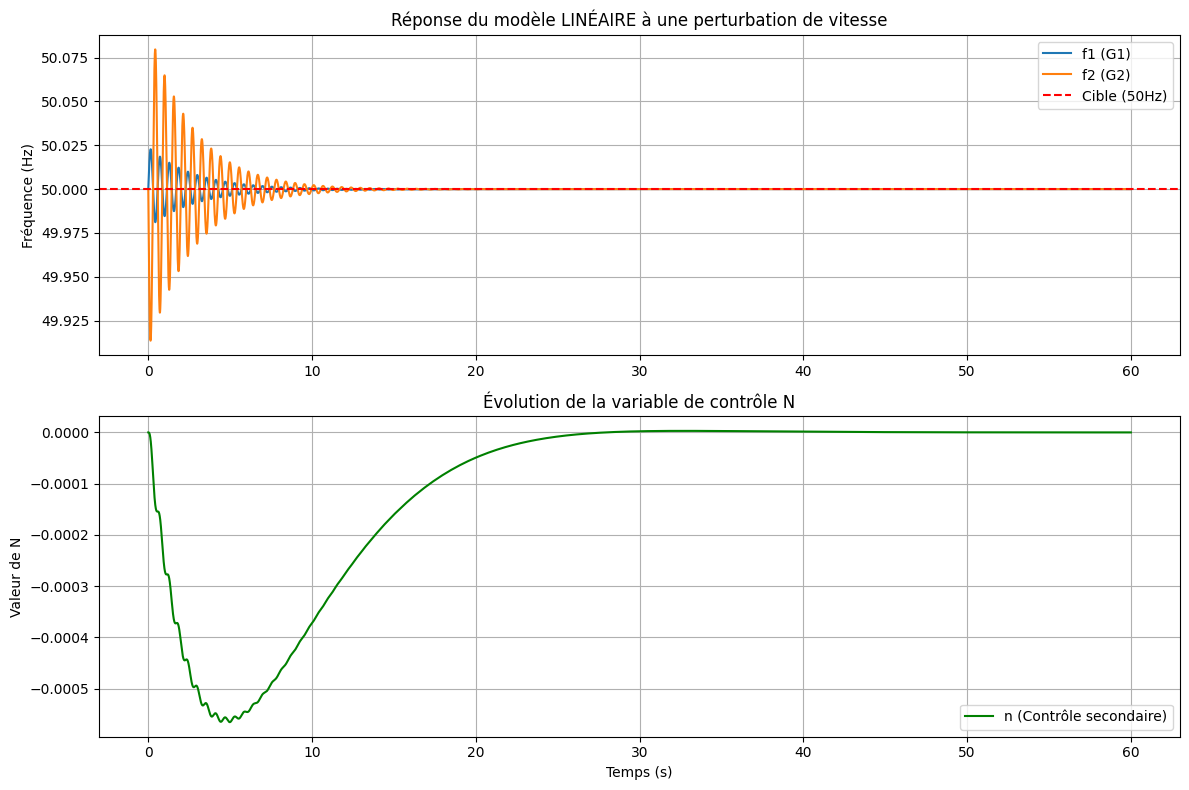

In [135]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Définition du point d'équilibre (Equilibrium) ---
# On utilise x0 comme point d'équilibre (xeq)

x0 = [0, params['omega0'], data['g1']['P0']/params['omega0'], 0, params['omega0'], data['g2']['P0']/params['omega0'], 0]
#-np.arcsin((data['g1']['P0'] - data['g1']['PL']) / data['KL'])
x_eq = np.array(x0).copy()
x_eq[3] = -np.arcsin((params['g1']['P0'] - params['g1']['PL0']) / params['KL_nom'])
u_eq = np.array([params['g1']['P0'], params['g2']['P0']])
w_eq = np.array([params['g1']['PL0'], params['g2']['PL0']])

# --- 2. Configuration de la simulation ---
dt = 0.00001  # Avec le modèle linéaire, 0.001s est généralement suffisant
t_final = 60.0
t_steps = np.arange(0, t_final, dt)

# --- 3. Initialisation des écarts (Delta X) ---
# Si on commence pile à l'équilibre, delta_x = 0
# Ajoutons une petite perturbation initiale sur la vitesse de G1 pour voir la dynamique
delta_x0 = x0 - x_eq
# delta_x0[1] = 0.1  # Perturbation de +0.1 rad/s sur omega1

delta_x_history = np.zeros((len(t_steps), len(delta_x0)))
delta_x_history[0] = delta_x0

# --- 4. Entrées (écarts par rapport au point de linéarisation) ---
# Si on ne change pas les consignes, delta_u et delta_w sont nuls
delta_u = np.array([0.0, 0.0]) 
delta_w = np.array([0.0, 0.0]) 

# --- 5. Boucle d'Euler ---
delta_x_current = delta_x0.copy()

for i in range(1, len(t_steps)):
    # Dynamique des écarts : d(delta_x)/dt = A*delta_x + B*delta_u + D*delta_w
    d_delta_x_dt = A_num @ delta_x_current + B_num @ delta_u + D_num @ delta_w
    
    # Mise à jour
    delta_x_current = delta_x_current + d_delta_x_dt * dt
    delta_x_history[i] = delta_x_current

# --- 6. Reconstruction des variables absolues pour l'affichage ---
# x_absolu = x_eq + delta_x
x_final_history = delta_x_history + x_eq

x_final_history[:, 1] = x_final_history[:, 1]/(2*np.pi)  # omega1
x_final_history[:, 4] = x_final_history[:, 4] / (2*np.pi)  # omega2

y_final_history = np.zeros((len(t_steps), 3))
for i in range(len(t_steps)):
    theta1_i = x_final_history[i, 0]
    theta2_i = x_final_history[i, 3]
    f12_i = params['KL_nom'] * (theta1_i - theta2_i)
    p1l_i = params['g1']['PL0']
    p2l_i = params['g2']['PL0']
    y_final_history[i, 0] = f12_i
    y_final_history[i, 1] = p1l_i + f12_i
    y_final_history[i, 2] = p2l_i - f12_i

# --- 7. Visualisation ---
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_steps, x_final_history[:, 1], label='f1 (G1)')
plt.plot(t_steps, x_final_history[:, 4], label='f2 (G2)')
plt.axhline(y=params['omega0'] / (2*np.pi), color='r', linestyle='--', label='Cible (50Hz)')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de vitesse")
plt.ylabel("Fréquence (Hz)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_steps, x_final_history[:, 6], label='n (Contrôle secondaire)', color='green')
plt.title("Évolution de la variable de contrôle N")
plt.xlabel("Temps (s)")
plt.ylabel("Valeur de N")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# --- 1. Discrétisation ---
Ad = np.eye(7) + A_num * dt
Bd = B_num * dt
Dd = D_num * dt
C_obs = C_num  # Jacobienne de Y par rapport à X (3x7)
E_obs = E_num # Impact direct de P1L et P2L sur Pg1/Pg2

# --- 2. Paramètres du filtre (Incertitudes) ---
V = np.eye(7) * 1e-6  # Bruit de processus (Confiance modèle)
W = np.eye(3) * 1e-3  # Bruit de mesure (Confiance capteurs)

# --- 3. Initialisation ---
delta_x_hat = delta_x0.copy().reshape(-1, 1) # Estimation initiale de l'écart
P_cov = np.eye(7) * 0.1                      # Incertitude initiale
delta_x_hat_history = np.zeros((len(t_steps), 7))

# Préparation des vecteurs colonnes pour les entrées (fixes dans ce scénario)
du = delta_u.reshape(-1, 1)
dw = delta_w.reshape(-1, 1)

y_reel_liste = np.array([F12_sim, P1G_sim, P2G_sim]).T[:len(t_steps)]

for i in range(len(t_steps)):
    # --- 1. ACQUISITION ET CALCUL DES ÉCARTS DE MESURE ---
    # On simule la mesure réelle totale y_k
    # y = [f12, pg1, pg2]
    x_reel = x_final_history[i].reshape(-1, 1)
    y_reel = y_final_history[i].reshape(-1, 1) + np.random.normal(0, 0.01, (3, 1))
    
    # Calcul de l'équilibre de mesure y_eq (pour obtenir l'écart delta_y)
    y_eq = C_obs @ x_eq.reshape(-1, 1) + E_obs @ w_eq.reshape(-1, 1)
    delta_y = y_reel - y_eq

    # --- 2. ÉTAPE DE PRÉDICTION (A Priori) ---
    delta_x_hat_minus = Ad @ delta_x_hat + Bd @ du + Dd @ dw
    P_minus = Ad @ P_cov @ Ad.T + V

    # --- 3. ÉTAPE DE CORRECTION (A Posteriori) ---
    # Innovation basée sur les écarts
    innovation = delta_y - (C_obs @ delta_x_hat_minus + E_obs @ dw)
    
    S = C_obs @ P_minus @ C_obs.T + W
    K = P_minus @ C_obs.T @ np.linalg.inv(S)
    
    delta_x_hat = delta_x_hat_minus + K @ innovation
    P_cov = (np.eye(7) - K @ C_obs) @ P_minus
    
    # Stockage de l'estimation de l'écart
    delta_x_hat_history[i] = delta_x_hat.flatten()

ValueError: x and y must have same first dimension, but have shapes (6000000,) and (1000,)

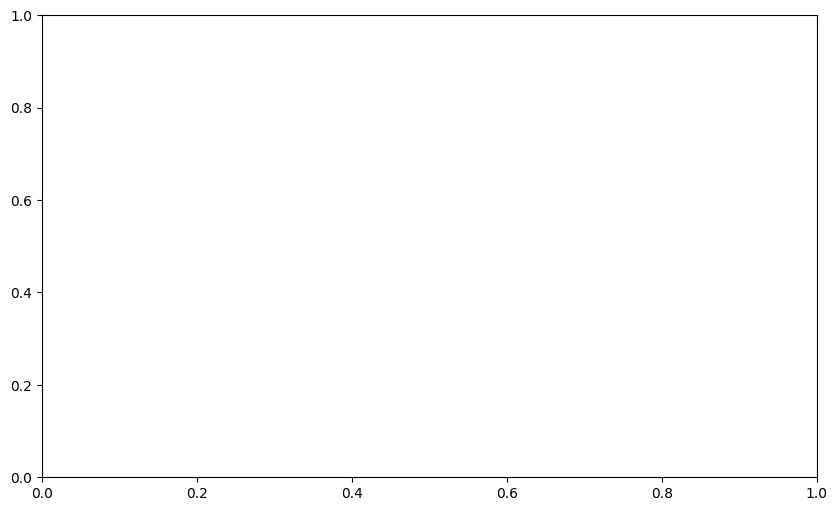

In [141]:
plt.figure(figsize=(10, 6))
plt.plot(t_steps, y_reel_liste[:,0], label='Mesure F12 (W)')
plt.title("Mesure simulée de la puissance échangée F12")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)") 
plt.grid(True)
plt.legend()
plt.show()

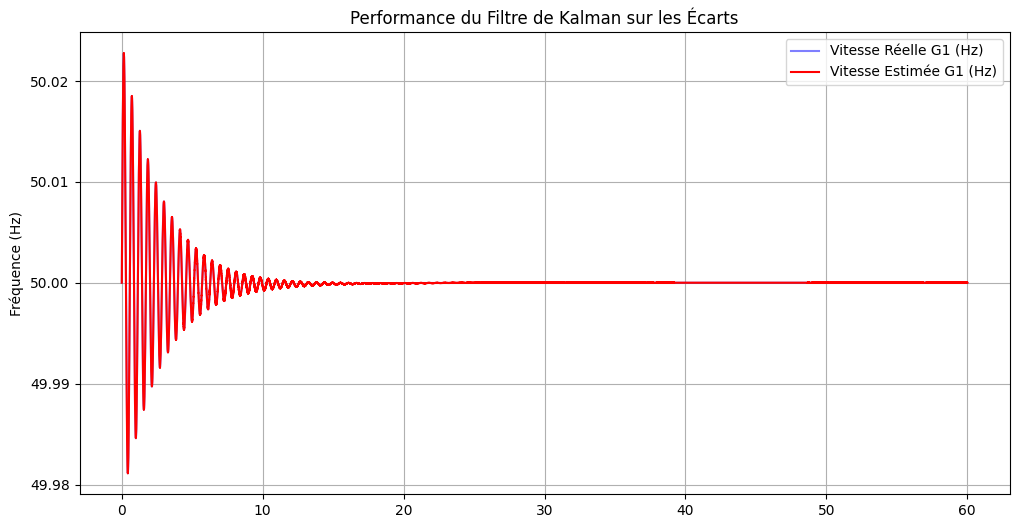

In [145]:
# Valeurs absolues estimées
x_hat_final = delta_x_hat_history + x_eq

plt.figure(figsize=(12, 6))
plt.plot(t_steps, x_final_history[:, 1], 'b', alpha=0.5, label='Vitesse Réelle G1 (Hz)')
plt.plot(t_steps, x_hat_final[:, 1] / (2*np.pi), 'r', label='Vitesse Estimée G1 (Hz)')
plt.title("Performance du Filtre de Kalman sur les Écarts")
plt.ylabel("Fréquence (Hz)")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\marin\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


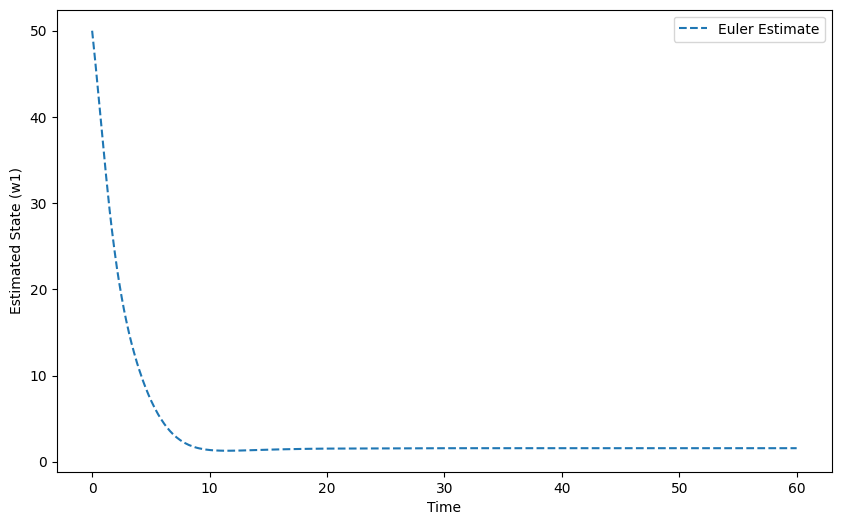

In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(t_steps, np.array(x_hat_history)[:, 1], label='Euler Estimate', linestyle='--')
plt.xlabel('Time')  
plt.ylabel('Estimated State (w1)')
plt.legend()
plt.show()

Filtre de Kalman

In [ ]:
import numpy as np

class PowerSystemKalmanFilter:
    def __init__(self, A, B, C, dt):
        # Discrétisation simple (Euler)
        self.Ad = np.eye(A.shape[0]) + A * dt
        self.Bd = B * dt
        self.C = C
        
        # Dimensions
        n = A.shape[0] # Nombre d'états (7)
        m = C.shape[0] # Nombre de mesures (ex: 3)

        # Matrices de Covariance (à ajuster selon la précision voulue)
        self.Q = np.eye(n) * 0.001  # Incertitude du modèle (Process Noise)
        self.R = np.eye(m) * 0.5    # Bruit des capteurs (Measurement Noise)
        
        # État initial
        self.x = np.zeros((n, 1))
        self.P = np.eye(n) # Incertitude initiale

    def step(self, u, z):
        """ u: commandes [P10, P20] """

        # --- 1. PRÉDICTION ---
        x_pred = self.Ad @ self.x + self.Bd @ u
        P_pred = self.Ad @ self.P @ self.Ad.T + self.Q

        # --- 2. CORRECTION (MISE À JOUR) ---
        # Innovation (Erreur entre mesure et prédiction)
        innovation = z - (self.C @ x_pred)
        # print("Measurement z:", z.flatten())
        # print("Prediction x_pred:", x_pred.flatten())
        # print("prediction z_pred : ", (self.C @ x_pred).flatten())
        # print("Innovation:", innovation.flatten())
        
        # Calcul du Gain de Kalman
        S = self.C @ P_pred @ self.C.T + self.R
        K = P_pred @ self.C.T @ np.linalg.inv(S)

        # Mise à jour de l'état et de la covariance
        self.x = x_pred + K @ innovation
        self.P = (np.eye(len(self.x)) - K @ self.C) @ P_pred
        
        return self.x

In [ ]:
# dt doit correspondre à la fréquence d'échantillonnage de vos capteurs
dt = 0.1 

# Création du filtre
kf = PowerSystemKalmanFilter(A_num, B_num, C_num, dt)

# Initialisation de l'état estimé (on peut commencer à l'équilibre)
kf.x = np.array(x0).reshape(-1, 1)

In [ ]:
# On récupère la fréquence de la machine 1 issue de la simulation
f12_true = F12_sim

# On crée une mesure "réelle" en ajoutant un bruit aléatoire
noise_std = 0.05
z_measured = f12_true + np.random.normal(0, noise_std, size=f12_true.shape)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Définition du point d'équilibre (Equilibrium) ---
# On utilise x0 comme point d'équilibre (xeq)

x0 = [0, params['omega0'], data['g1']['P0']/params['omega0'], 0, params['omega0'], data['g2']['P0']/params['omega0'], 0]
#-np.arcsin((data['g1']['P0'] - data['g1']['PL']) / data['KL'])
x_eq = np.array(x0).copy()
x_eq[3] = -np.arcsin((params['g1']['P0'] - params['g1']['PL0']) / params['KL_nom'])
u_eq = np.array([params['g1']['P0'], params['g2']['P0']])
w_eq = np.array([params['g1']['PL0'], params['g2']['PL0']])

# --- 2. Configuration de la simulation ---
dt = 0.00001  # Avec le modèle linéaire, 0.001s est généralement suffisant
t_final = 60.0
t_steps = np.arange(0, t_final, dt)

# --- 3. Initialisation des écarts (Delta X) ---
# Si on commence pile à l'équilibre, delta_x = 0
# Ajoutons une petite perturbation initiale sur la vitesse de G1 pour voir la dynamique
delta_x0 = x0 - x_eq
# delta_x0[1] = 0.1  # Perturbation de +0.1 rad/s sur omega1

delta_x_history = np.zeros((len(t_steps), len(delta_x0)))
delta_x_history[0] = delta_x0

# --- 4. Entrées (écarts par rapport au point de linéarisation) ---
# Si on ne change pas les consignes, delta_u et delta_w sont nuls
delta_u = np.array([0.0, 0.0]) 
delta_w = np.array([0.0, 0.0]) 

# --- 5. Boucle d'Euler ---
delta_x_current = delta_x0.copy()

for i in range(1, len(t_steps)):
    # Dynamique des écarts : d(delta_x)/dt = A*delta_x + B*delta_u + D*delta_w
    d_delta_x_dt = A_num @ delta_x_current + B_num @ delta_u + D_num @ delta_w
    
    # Mise à jour
    delta_x_current = delta_x_current + d_delta_x_dt * dt
    delta_x_history[i] = delta_x_current

# --- 6. Reconstruction des variables absolues pour l'affichage ---
# x_absolu = x_eq + delta_x
x_final_history = delta_x_history + x_eq

x_final_history[:, 1] = x_final_history[:, 1]/(2*np.pi)  # omega1
x_final_history[:, 4] = x_final_history[:, 4] / (2*np.pi)  # omega2

# --- 7. Visualisation ---
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_steps, x_final_history[:, 1], label='f1 (G1)')
plt.plot(t_steps, x_final_history[:, 4], label='f2 (G2)')
plt.axhline(y=params['omega0'] / (2*np.pi), color='r', linestyle='--', label='Cible (50Hz)')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de vitesse")
plt.ylabel("Fréquence (Hz)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_steps, x_final_history[:, 6], label='n (Contrôle secondaire)', color='green')
plt.title("Évolution de la variable de contrôle N")
plt.xlabel("Temps (s)")
plt.ylabel("Valeur de N")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# plt.figure(figsize=(10, 5))
# plt.plot(sol.t, f12_true, label="Vrai (Physique)", color='green', alpha=0.5)
# plt.plot(sol.t, z_measured, label="Mesuré (Bruit)", color='red', alpha=0.3)
# plt.plot(sol.t, estimated_states[:, 1], label="Estimé (Kalman)", color='blue')
# plt.title("Estimation de la fréquence par Filtre de Kalman")
# plt.legend()
# plt.show()

In [ ]:
# import pandas as pd
# import plotly.express as px

# # On suppose que estimated_states[:, 1] correspond à l'estimation de w1
# # et que z_measured est la mesure bruitée de w1
# df_plot = pd.DataFrame({
#     'Temps (s)': sol.t,
#     'Vrai (Physique)': f12_true,      # La valeur réelle issue de solve_ivp
#     'Mesuré (Bruit)': z_measured.flatten(), # La valeur envoyée au filtre
#     'Estimé (Kalman)': estimated_states[:, 1], # La sortie du filtre
#     'euler_states': np.array(euler_states)[:,1]  # La valeur estimée par Euler
# })

# # Conversion du format "large" au format "long" pour Plotly
# df_melted = df_plot.melt(id_vars=['Temps (s)'], 
#                          var_name='Type', 
#                          value_name='Valeur')

# fig = px.line(df_melted, 
#               x='Temps (s)', 
#               y='Valeur', 
#               color='Type',
#               title="Analyse de l'Estimation par Filtre de Kalman (Fréquence)",
#               labels={'Valeur': 'Fréquence (rad/s)'},
#               template='plotly_white')

# # Personnalisation des épaisseurs et opacités
# fig.update_traces(line=dict(width=1), selector=dict(name='Mesuré (Bruit)'), opacity=0.4)
# fig.update_traces(line=dict(width=2), selector=dict(name='Estimé (Kalman)'))

# fig.show()

In [ ]:
import numpy as np
estimated_states = []

x_euler = np.array(x0).reshape(-1, 1) # État initial pour Euler
euler_states = [x_euler.flatten()]

# Références d'équilibre pour le calcul des écarts
x_eq = np.array(x0).reshape(-1, 1)
u_eq = np.array([[data['g1']['P0']], [data['g2']['P0']]])

estimated_states = []

start = 0.0
end = 60.0
step = 0.00005
time = np.arange(start, end, step)

for i in range(1,len(time)):
    
    # Calcul du pas de temps réel (dt)
    dt = step 
    
    # --- A. PRÉPARATION DES ENTRÉES (U et V) ---
    u_k = np.array([[data['g1']['P0']], [data['g2']['P0']]])
    # p1l_k, p2l_k, _ = get_disturbances(time[i], 'EL1', data)
    # v_k = np.array([[p1l_k], [p2l_k]])
    
    # Calcul de la dérivée : dx/dt = A(x-xeq) + B(u-ueq) + E(v-veq)
    # On travaille en écarts (Delta) par rapport à l'équilibre
    dx = x_euler - x_eq
    # print(dx.shape)
    du = u_k - u_eq
    dv = np.array([[0, 0]]).reshape(-1,1) 
    # print("Disturbance v_k at time", sol.t[i], ":", dv.flatten())
    
    
    # print('shape A_num:', A_num.shape)
    # print('shape dx:', dx.shape)
    # print('shape B_num:', B_num.shape)
    # print('shape du:', du.shape)
    # print('shape D_num:', D_num.shape)
    # print('shape dv:', dv.shape)
    x_dot = A_num @ dx + B_num @ du + D_num @ dv
    # print("x_dot at time", sol.t[i], ":", x_dot.flatten())
    # Mise à jour d'Euler : x(t+dt) = x(t) + x_dot * dt
    x_euler = x_euler + x_dot * dt
    # print(x_euler.shape)
    euler_states.append(x_euler.flatten())

# df_euler = pd.DataFrame({
#     'Temps (s)': np.linspace(0, len(euler_states) * step, len(euler_states)),
#     'tetha1 (rad)': np.array(euler_states)[:, 0],
#     'Fréquence w1 (rad/s)': np.array(euler_states)[:, 1],
#     'Tm1 (MWs)': np.array(euler_states)[:, 2],
#     'tetha2 (rad)': np.array(euler_states)[:, 3],
#     'Fréquence w2 (rad/s)': np.array(euler_states)[:, 4],
#     'Tm2 (MWs)': np.array(euler_states)[:, 5],
#     'N (Contrôle Secondaire)': np.array(euler_states)[:, 6]
# })




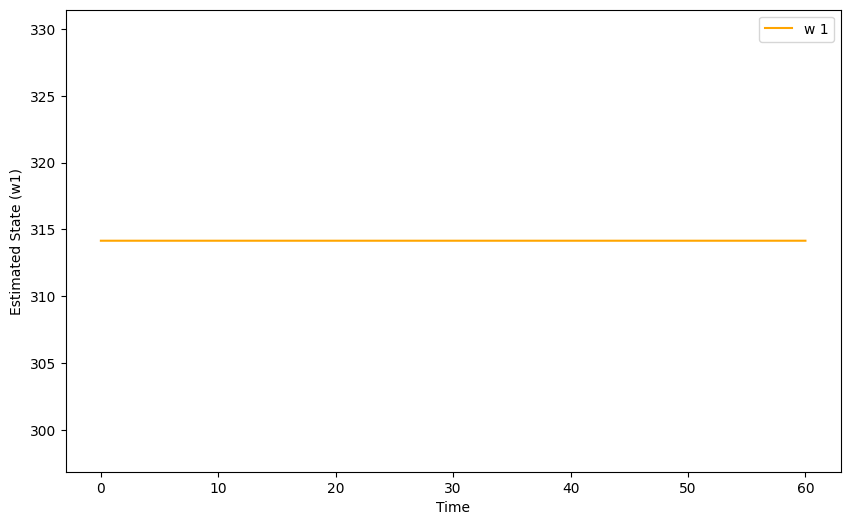

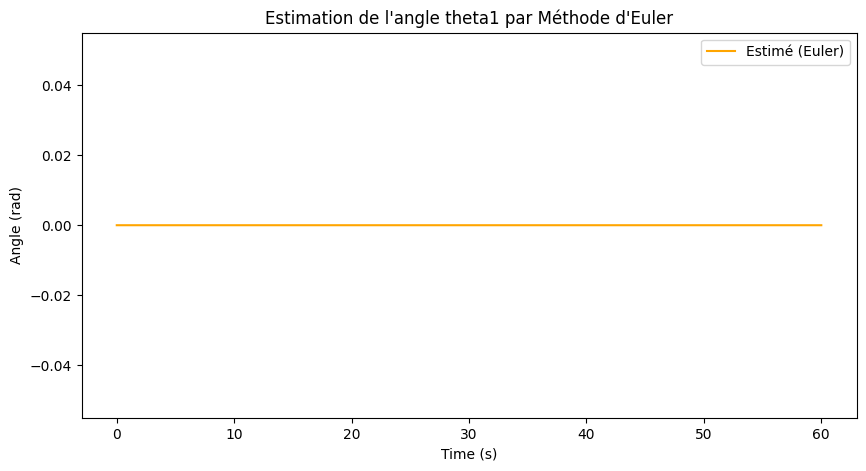

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(time, np.array(euler_states)[:, 1], label='w 1', color='orange')
# plt.plot(time,np.array(euler_states)[:, 3], label='w 2', color='green')
plt.xlabel('Time')  
plt.ylabel('Estimated State (w1)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(time, np.array(euler_states)[:, 0], label="Estimé (Euler)", color='orange')
#plt.plot(time, np.array(euler_states)[:, 4], label="Estimé (Euler)", color='green')
plt.title("Estimation de l'angle theta1 par Méthode d'Euler")
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.legend()
plt.show()

In [ ]:
import plotly.express as px

fig = px.line(df_euler, x='Temps (s)', y=['Fréquence w1 (rad/s)', 'Fréquence w2 (rad/s)'],
              title="Estimation des Fréquences par Méthode d'Euler",
                labels={'value': 'Fréquence (rad/s)', 'variable': 'Machines'},
                template='plotly_white')
# Personnalisation des épaisseurs et opacités
fig.update_traces(line=dict(width=2))
fig.show()

fig = px.line(df_euler, x='Temps (s)', y=['tetha1 (rad)', 'tetha2 (rad)'],
              title="Estimation des Angles des Rotors par Méthode d'Euler",
                labels={'value': 'Angle (rad)', 'variable': 'Machines'},
                template='plotly_white')
# Personnalisation des épaisseurs et opacités
fig.update_traces(line=dict(width=2))
fig.show()

fig = px.line(df_euler, x='Temps (s)', y=['Tm1 (MWs)', 'Tm2 (MWs)'],
              title="Estimation des Puissances Mécaniques par Méthode d'Euler",
                labels={'value': 'Puissance (MWs)', 'variable': 'Machines'},
                template='plotly_white')
# Personnalisation des épaisseurs et opacités
fig.update_traces(line=dict(width=2))
fig.show()

NameError: name 'df_euler' is not defined